In [ ]:
#These are libraries that you should import if needed for your notebook.
#import libraries
import pandas as pd
import seaborn as sns
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')
from google.colab import files

**A/B Testing** is a statistical method used to compare two versions of something to determine which performs better.

For example, a company may want to compare two website designs:

* Version A: Original design
* Version B: New design

Users are randomly divided into two groups. One group sees Version A and the other sees Version B. Their responses are then compared.

**How A/B Testing Works**
* Define the goal
Decide what you want to improve, such as clicks, sales, sign-ups, or engagement.
* Create two versions
Version A is usually the current version, while Version B contains the proposed change.
* Randomly assign participants
Users are randomly divided into two groups to reduce bias.
* Collect results
Measure the outcome for each group.
* Compare the results
Determine whether the difference between A and B is large enough to suggest that one version performs better

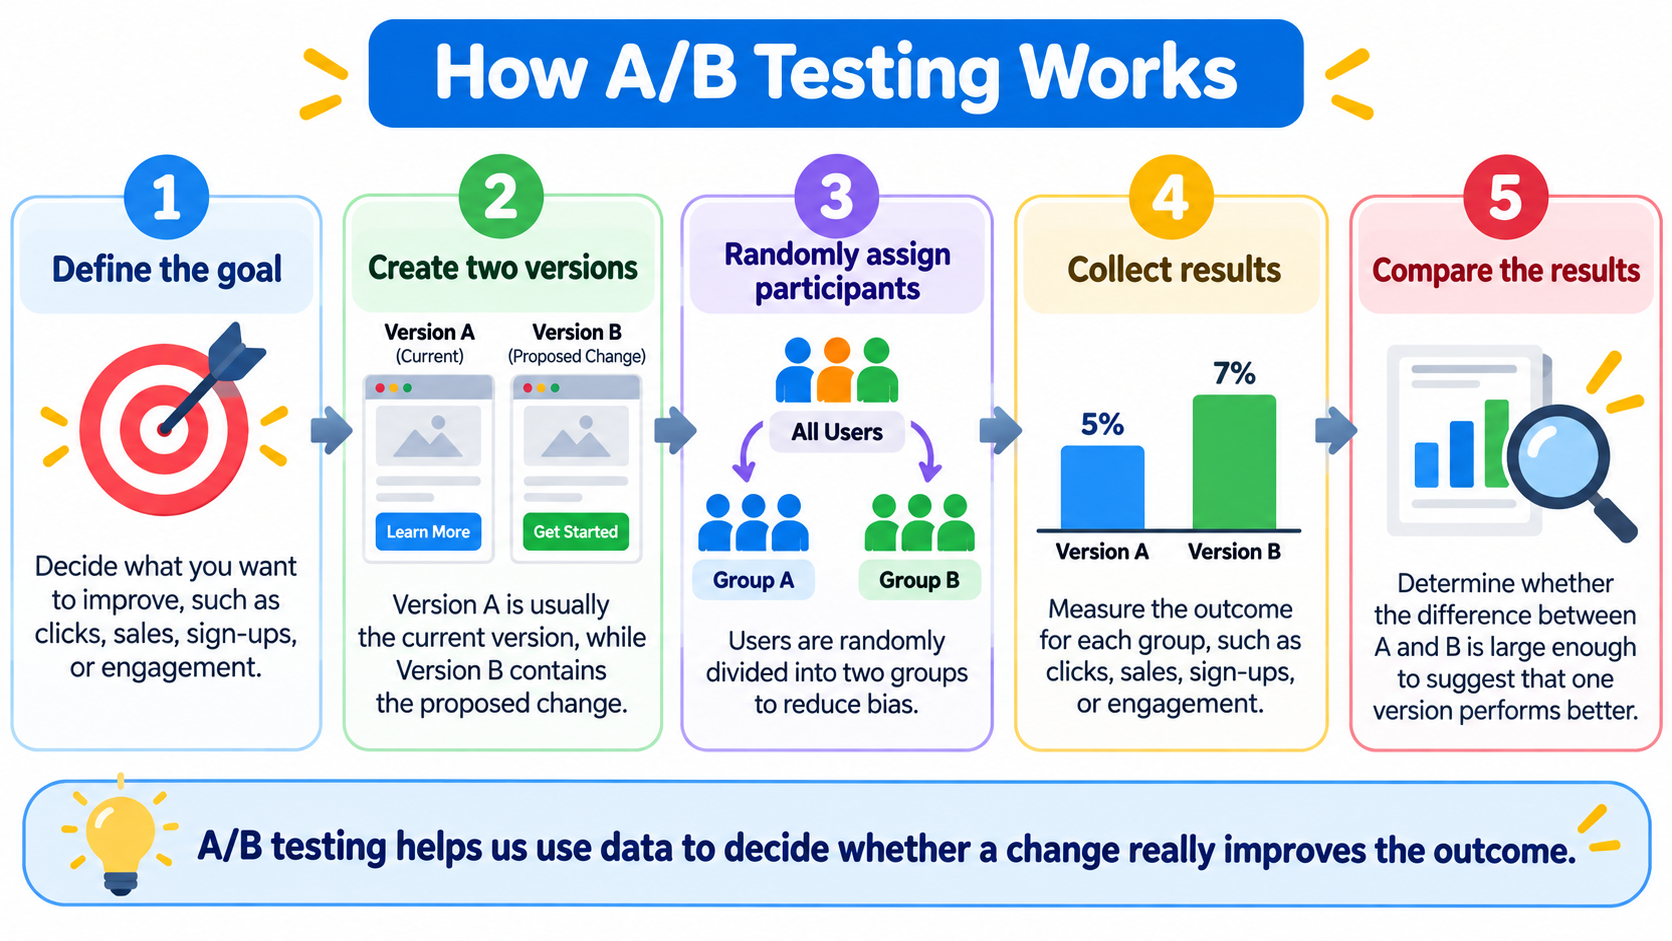

# Comparing Two Samples

In [ ]:
#upload the file baby.csv


In [ ]:
#Read the file baby.csv


In [ ]:
#create a new table only with Maternal Smoker and Birth Weight

In [ ]:
#Determine the number of non smokers and smokers


In [ ]:
#plot the grouped data into a histogram
grouped = smoking_and_birthweight.groupby('Maternal Smoker')
for category, group in grouped:
  plots.hist(group['Birth Weight'],label = f'Category {category}')

plots. legend()

# Test Statistic

[Question] What values of our statistic are in favor of the alternative: positive or negative?

In [ ]:
#Determine the mean of the birth weight for smokers vs non-smokers



In [ ]:
#What is the difference between the birth weight for smokers and non-smokers


In [ ]:
#Create a function to input a table, a label and group label. which would then determine the label difference grouped by the values in group label

def difference_of_means(table, label, group_label):
    """Takes: name of table, column label of numerical variable,
    column label of group-label variable
    Returns: Difference of means of the two groups"""

    reduced = table[[label, group_label]]

    mean_table = reduced.groupby(group_label).mean()
    means_difference = mean_table.iloc[1,:]-mean_table.iloc[0,:]

    return means_difference.to_numpy()[0]

In [ ]:
#Let's test thi


# Random Permutation (Shuffling)

In [ ]:
#Let's create a table



In [ ]:
#Let's shuffle with replacement


In [ ]:
#Let's shuffle without replacement


In [ ]:
#Let's put the shuffle without replacement as a column into the table, letters.


# Simulation Under Null Hypothesis

In [ ]:
#Call table smoking_and_birthwei


In [ ]:
#Create an array with maternal smoker column being shuffled
shuffled_labels = np.random.permutation(smoking_and_birthweight['Maternal Smoker'])
shuffled_labels

In [ ]:
#Create a new table original_and_shuffled and add the shuffled labels as a column
original_and_shuffled = smoking_and_birthweight
original_and_shuffled['Shuffled Label'] = shuffled_labels
original_and_shuffled

In [ ]:
#determine the difference mean in birth weight for shuffled label


In [ ]:
#determine the difference mean in birth weight for Maternal smoker


# Permutation Test

In [ ]:
#Let's put this all into a function
def one_simulated_difference(table, label, group_label):
    """Takes: name of table, column label of numerical variable,
    column label of group-label variable
    Returns: Difference of means of the two groups after shuffling labels"""

    # array of shuffled labels
    shuffled_labels = np.random.permutation(table[group_label])

    # table of numerical variable and shuffled labels
    table['Shuffled Label'] = shuffled_labels

    return difference_of_means(table, label, 'Shuffled Label')

In [ ]:
#Test this function


In [ ]:
#Let's run this multiple times
differences = []
for i in np.arange(2500):
  new_difference = one_simulated_difference(births, 'Birth Weight','Maternal Smoker')
  differences.append(new_difference)

In [ ]:
#Let's plot the distribution from the results above
table = pd.DataFrame({'Difference Between Group Means' : differences})
table.hist('Difference Between Group Means')

print('Observed Difference:', observed_difference)